In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 3")

## Section 1 : Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='darkgrid')

## Section 2 : Load Data set

In [5]:
data = pd.read_csv('BTC-USD.csv', parse_dates=['Date'])

print(f"\nDataset Shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
print(f"Memory Usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Dataset Shape: 3,566 rows × 7 columns
Memory Usage: 0.36 MB


In [6]:
# Display first few rows
print("\nFirst 5 rows of the dataset:")
data.head()


First 5 rows of the dataset:


,Date,Open,High,Low,Close,Adj Close,Volume
0,10-10-2014,364.687012,375.066986,352.963013,361.562012,361.562012,43665700.0
1,11-10-2014,361.362000,367.191010,355.950989,362.299011,362.299011,13345200.0
2,12-10-2014,362.605988,379.433014,356.144012,378.549011,378.549011,17552800.0
3,13-10-2014,377.920990,397.226013,368.897003,390.414001,390.414001,35221400.0
4,14-10-2014,391.691986,411.697998,391.324005,400.869995,400.869995,38491500.0


In [7]:
# Display last few rows
print("\nLast 5 rows of the dataset:")
data.tail()


Last 5 rows of the dataset:


,Date,Open,High,Low,Close,Adj Close,Volume
3561,10-07-2024,58033.88281,59359.43359,57178.41406,57742.49609,57742.49609,2.617526e+10
3562,11-07-2024,57729.89063,59299.43359,57120.37891,57344.91406,57344.91406,2.870780e+10
3563,12-07-2024,57341.19531,58532.55469,56590.17578,57899.46484,57899.46484,2.560481e+10
3564,13-07-2024,57908.73828,59787.07813,57796.44141,59231.95313,59231.95313,1.708006e+10
3565,14-07-2024,59225.25000,60363.85938,59225.25000,60245.80469,60245.80469,2.140587e+10


In [8]:
# Display random sample
print("\nRandom sample of 5 rows:")
data.sample(5, random_state=42)


Random sample of 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
869,25-02-2017,1170.410034,1174.849976,1124.589966,1143.839966,1143.839966,1.399610e+08
3420,20-02-2024,51777.726560,52945.050780,50792.312500,52284.875000,52284.875000,3.335376e+10
351,26-09-2015,235.076004,235.403000,233.358002,234.339996,234.339996,1.372410e+07
927,24-04-2017,1209.630005,1250.939941,1209.630005,1250.150024,1250.150024,2.358060e+08
1820,04-10-2019,8259.494141,8260.055664,8151.236816,8205.939453,8205.939453,1.313946e+10


In [10]:
print(data.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [12]:
data['Date'] = pd.to_datetime(
    data['Date'],
    format='%d-%m-%Y',
    errors='raise'
)

data.set_index('Date', inplace=True)
data.sort_index(inplace=True)

In [13]:
print(data.index.min(), data.index.max())

2014-10-10 00:00:00 2024-07-14 00:00:00


In [14]:
print(f'Date Range    : {data.index.min().date()} → {data.index.max().date()}')
print(f'Total Days    : {(data.index.max() - data.index.min()).days}')

Date Range    : 2014-10-10 → 2024-07-14
Total Days    : 3565


## Section 3 : Data Overview

In [15]:
# Column info
data.info()
print()
data.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3566 entries, 2014-10-10 to 2024-07-14
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       3566 non-null   float64
 1   High       3566 non-null   float64
 2   Low        3566 non-null   float64
 3   Close      3566 non-null   float64
 4   Adj Close  3566 non-null   float64
 5   Volume     3566 non-null   float64
dtypes: float64(6)
memory usage: 195.0 KB



,Open,High,Low,Close,Adj Close,Volume
count,3566.00,3566.00,3566.00,3566.00,3566.00,3.566000e+03
mean,17130.77,17521.65,16713.15,17146.36,17146.36,1.746206e+10
std,18911.21,19338.26,18441.41,18920.81,18920.81,1.917847e+10
min,176.90,211.73,171.51,178.10,178.10,5.914570e+06
25%,1164.66,1186.74,1126.91,1166.92,1166.92,2.928932e+08
50%,8940.44,9202.83,8790.99,8987.82,8987.82,1.363268e+10
75%,28084.28,28531.55,27534.17,28148.96,28148.96,2.805912e+10
max,73079.38,73750.07,71334.09,73083.50,73083.50,3.509680e+11


## Section 4 : Data PreProcessing

In [16]:
# --- Missing Values ---
print('Missing Values:')
print(data.isnull().sum())
print(f'\nTotal missing: {data.isnull().sum().sum()}')

Missing Values:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Total missing: 0


In [17]:
# --- Duplicates ---
print(f'Duplicate date entries: {data.index.duplicated().sum()}')
df = data[~data.index.duplicated(keep='first')]

Duplicate date entries: 0


In [18]:
# --- Drop Adj Close (same as Close for BTC) ---
df.drop(columns=['Adj Close'], inplace=True)

In [19]:
# --- Ensure numeric types ---
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.ffill(inplace=True)

In [20]:
# --- Outlier check via Z-score ---
z_scores = np.abs(stats.zscore(df[['Close', 'Volume']]))
outliers = (z_scores > 4).sum()
print(f'\nOutliers (|Z| > 4):')
print(outliers)
print('\n Preprocessing complete!')
df.shape


Outliers (|Z| > 4):
11

 Preprocessing complete!


(3566, 5)

In [21]:
print(type(df.index))
print(df.index.dtype)

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
datetime64[ns]


In [22]:
df.index = pd.to_datetime(df.index)
df = df.sort_index()

df_weekly     = df['Close'].resample('W').last()
df_monthly    = df['Close'].resample('M').last()
df_quarterly  = df['Close'].resample('Q').last()

print(f'Daily    : {len(df)} records')
print(f'Weekly   : {len(df_weekly)} records')
print(f'Monthly  : {len(df_monthly)} records')
print(f'Quarterly: {len(df_quarterly)} records')

Daily    : 3566 records
Weekly   : 510 records
Monthly  : 118 records
Quarterly: 40 records


## Section 5 : EDA Analysis

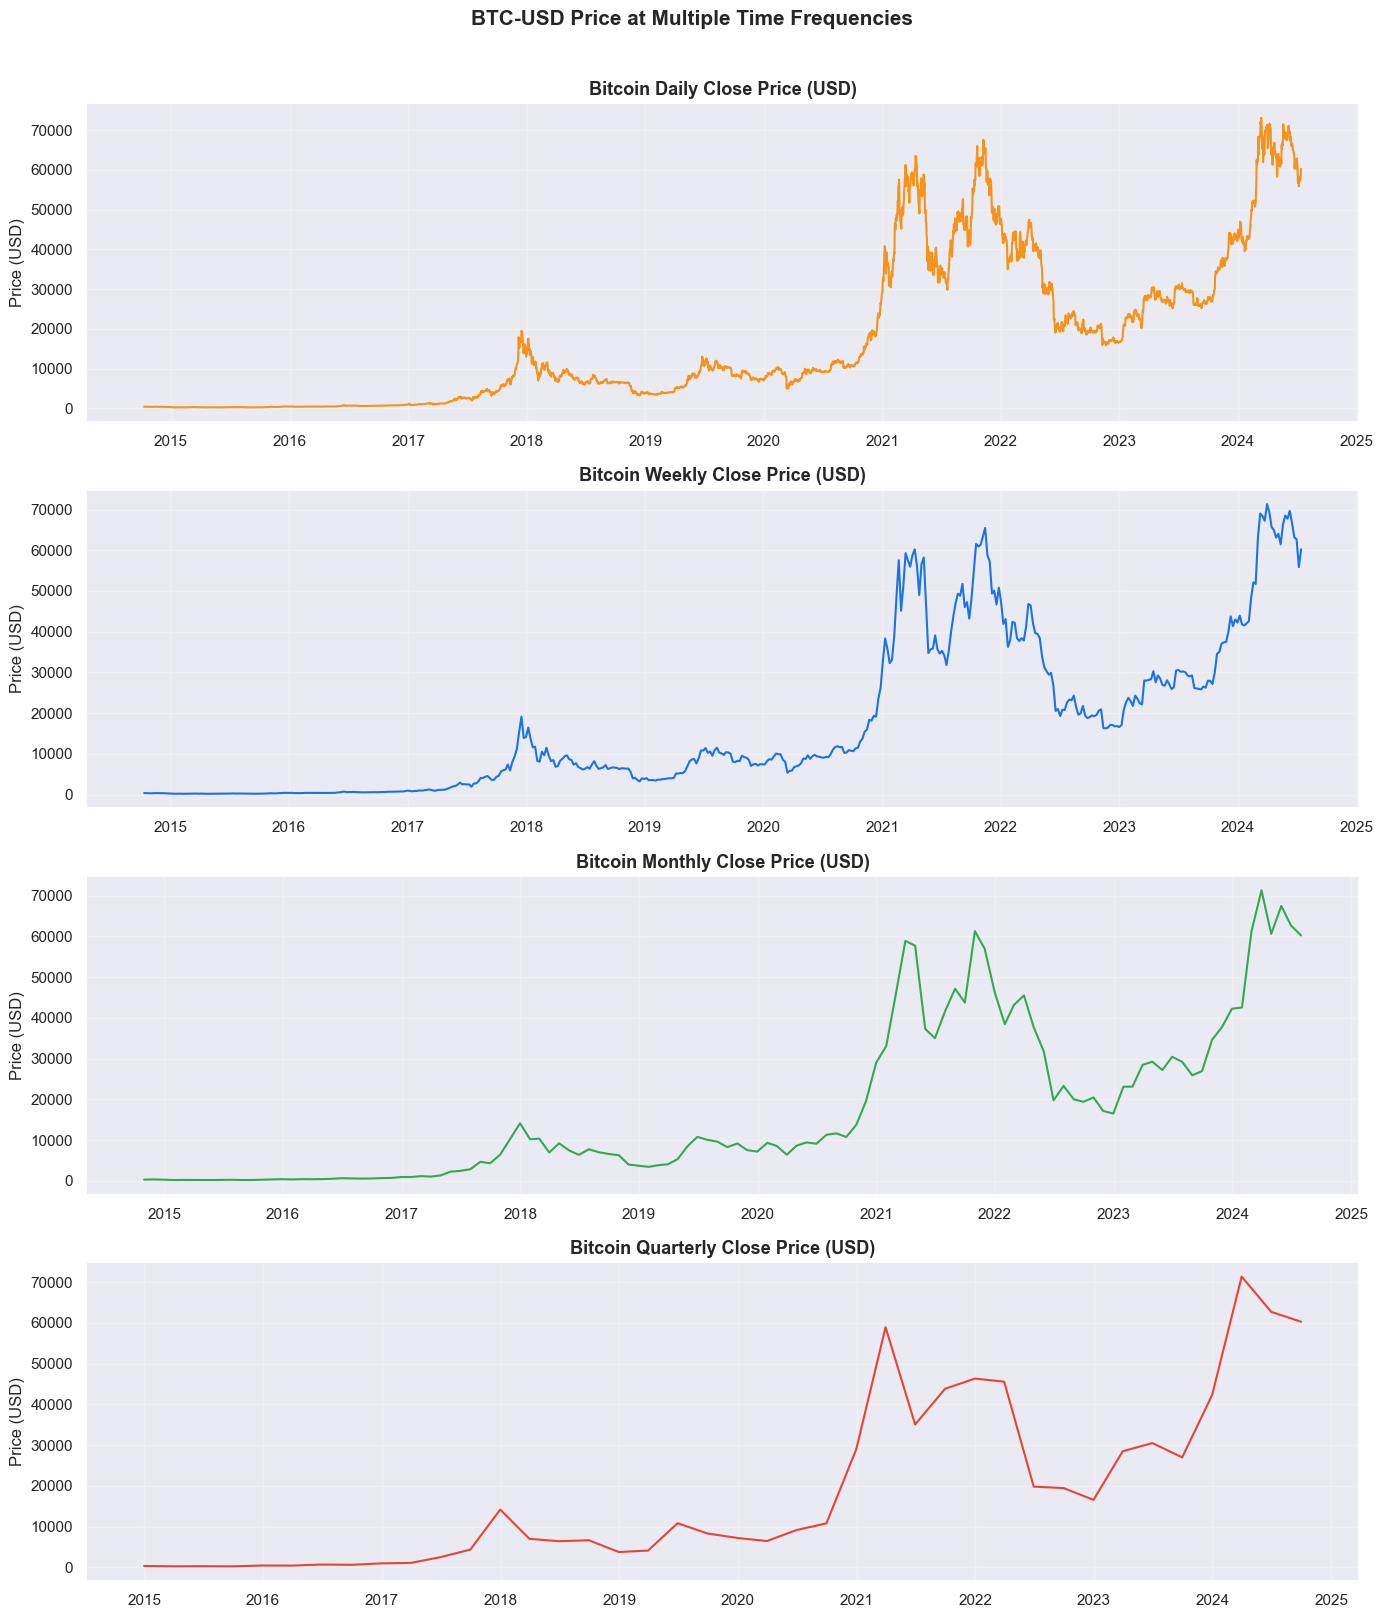

In [23]:
# ── Multi-Frequency Price Trends ──
fig, axes = plt.subplots(4, 1, figsize=(14, 16))
freqs = [
    (df['Close'],    'Daily',     '#F7931A'),
    (df_weekly,      'Weekly',    '#1A73E8'),
    (df_monthly,     'Monthly',   '#34A853'),
    (df_quarterly,   'Quarterly', '#EA4335'),
]
for ax, (series, label, color) in zip(axes, freqs):
    ax.plot(series.index, series.values, color=color, linewidth=1.5)
    ax.set_title(f'Bitcoin {label} Close Price (USD)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('BTC-USD Price at Multiple Time Frequencies', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('nb1_01_price_trends.png', dpi=150, bbox_inches='tight')
plt.show()

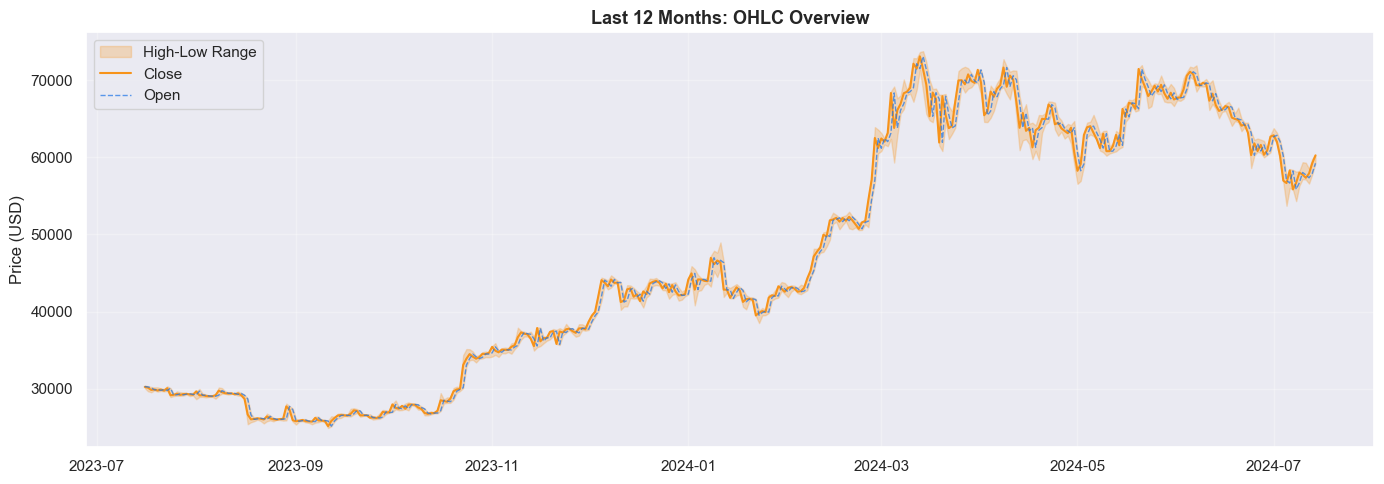

In [24]:
# ── OHLC Overview (Last 12 Months) ──
recent = df.last('365D')

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(recent.index, recent['Low'], recent['High'], alpha=0.25, color='#F7931A', label='High-Low Range')
ax.plot(recent.index, recent['Close'], color='#F7931A', linewidth=1.5, label='Close')
ax.plot(recent.index, recent['Open'],  color='#1A73E8', linewidth=1,   linestyle='--', alpha=0.7, label='Open')
ax.set_title('Last 12 Months: OHLC Overview', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('nb1_02_ohlc.png', dpi=150, bbox_inches='tight')
plt.show()

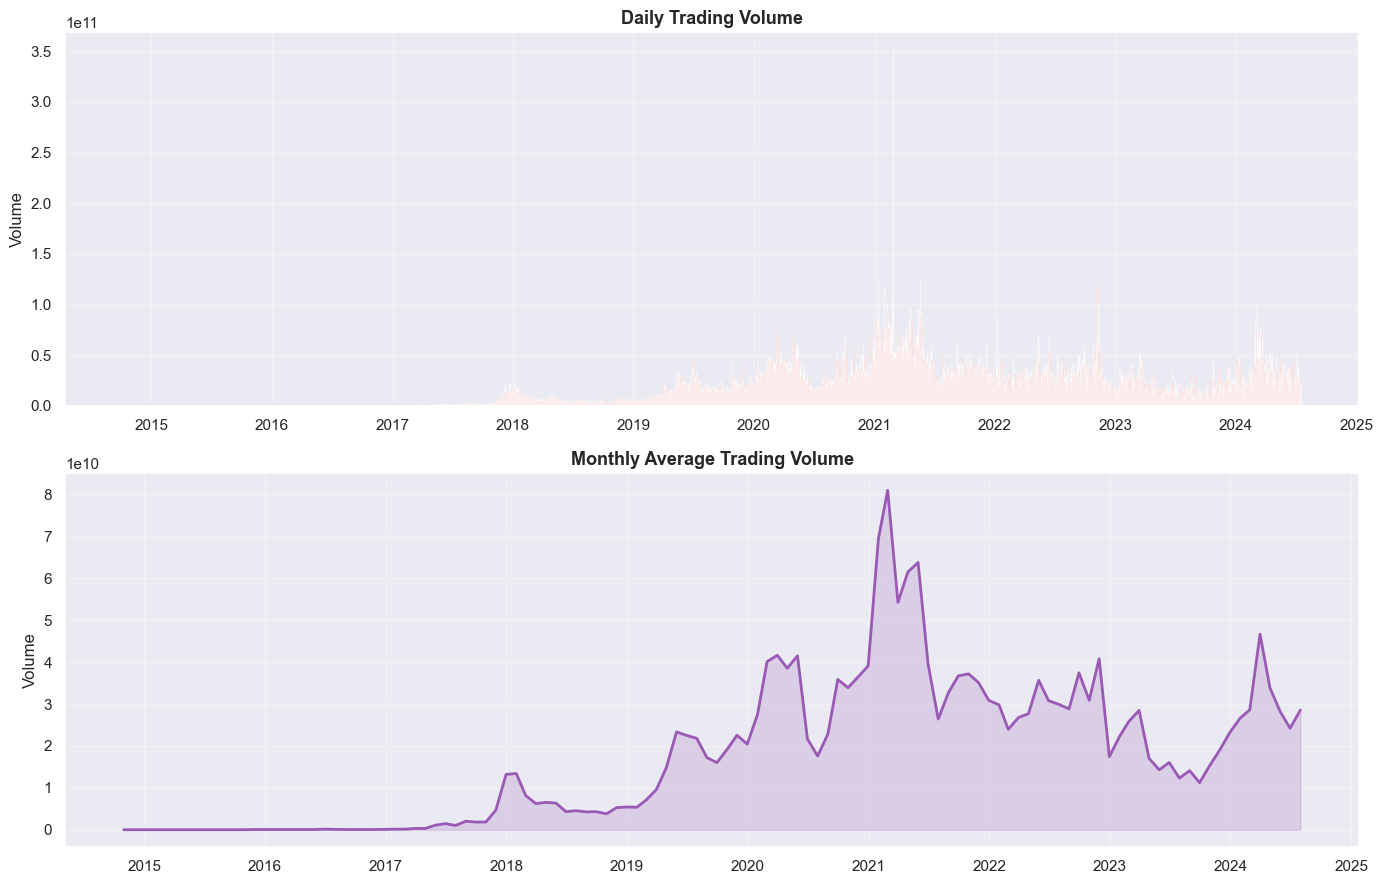

In [26]:
# ── Volume Analysis ──
df_vol_monthly = df['Volume'].resample('ME').mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].bar(df.index, df['Volume'], color='#EA4335', alpha=0.6, width=1)
axes[0].set_title('Daily Trading Volume', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Volume')

axes[1].plot(df_vol_monthly.index, df_vol_monthly.values, color='#9B59B6', linewidth=2)
axes[1].fill_between(df_vol_monthly.index, 0, df_vol_monthly.values, alpha=0.2, color='#9B59B6')
axes[1].set_title('Monthly Average Trading Volume', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volume')

plt.tight_layout()
plt.savefig('nb1_03_volume.png', dpi=150, bbox_inches='tight')
plt.show()

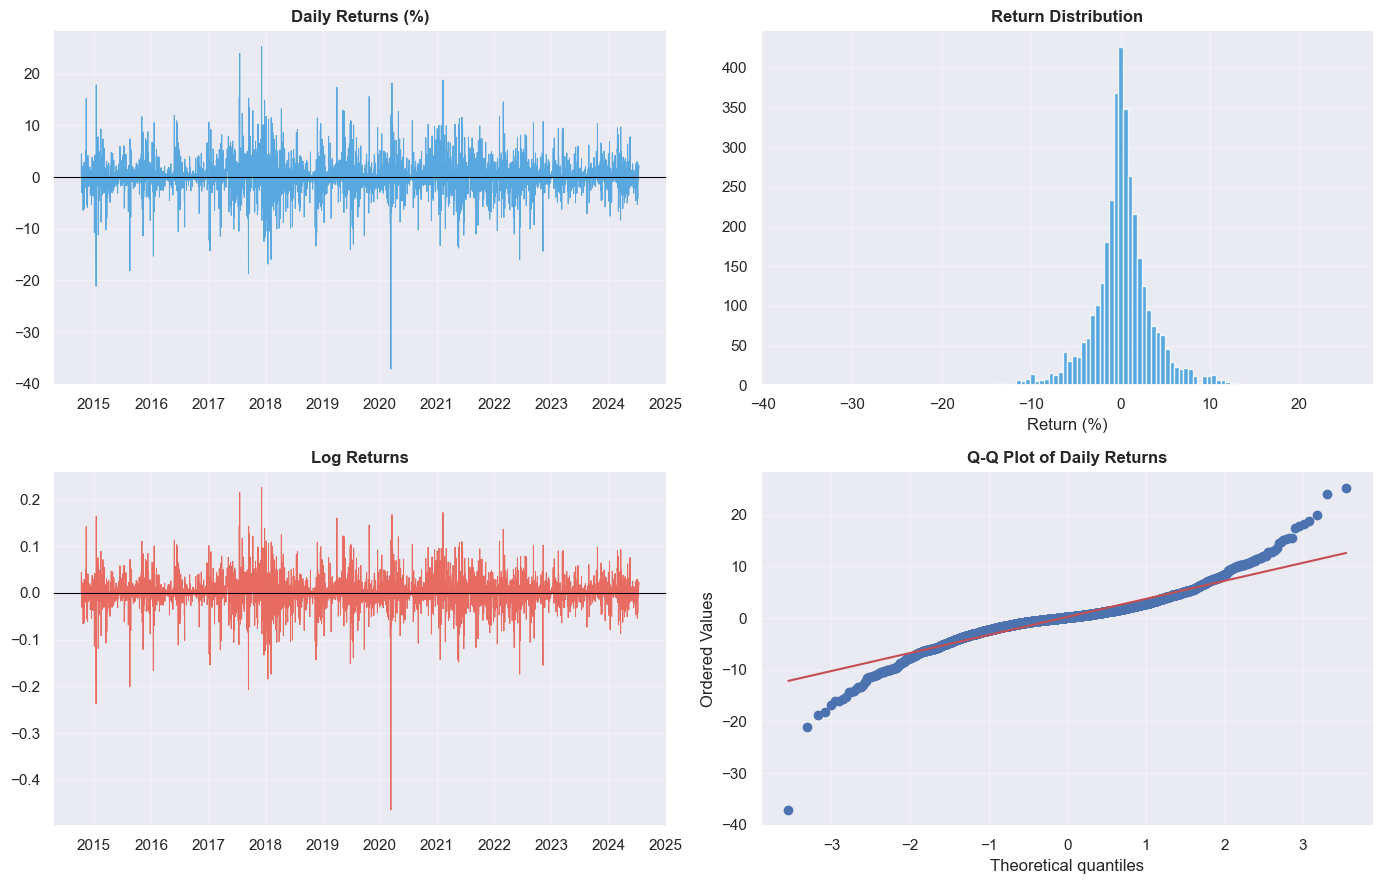

Mean Return  : 0.2109%
Std Return   : 3.6527%
Skewness     : -0.1309
Kurtosis     : 7.6374


In [27]:
# ── Daily Returns Analysis ──
df['Daily_Return'] = df['Close'].pct_change() * 100
df['Log_Return']   = np.log(df['Close'] / df['Close'].shift(1))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Return over time
axes[0, 0].plot(df.index, df['Daily_Return'], color='#3498DB', linewidth=0.7, alpha=0.8)
axes[0, 0].axhline(0, color='black', linewidth=0.8)
axes[0, 0].set_title('Daily Returns (%)', fontsize=12, fontweight='bold')

# Histogram
axes[0, 1].hist(df['Daily_Return'].dropna(), bins=120, color='#3498DB', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Return Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Return (%)')

# Log Return
axes[1, 0].plot(df.index, df['Log_Return'], color='#E74C3C', linewidth=0.7, alpha=0.8)
axes[1, 0].axhline(0, color='black', linewidth=0.8)
axes[1, 0].set_title('Log Returns', fontsize=12, fontweight='bold')

# QQ Plot
stats.probplot(df['Daily_Return'].dropna(), dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Daily Returns', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('nb1_04_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean Return  : {df["Daily_Return"].mean():.4f}%')
print(f'Std Return   : {df["Daily_Return"].std():.4f}%')
print(f'Skewness     : {df["Daily_Return"].skew():.4f}')
print(f'Kurtosis     : {df["Daily_Return"].kurt():.4f}')

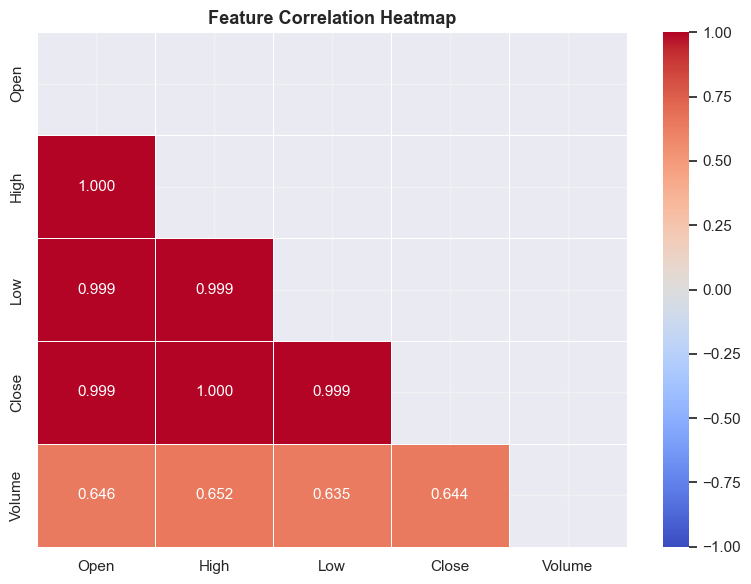

In [28]:
# ── Correlation Heatmap ──
plt.figure(figsize=(8, 6))
corr = df[['Open','High','Low','Close','Volume']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 11})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nb1_05_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1400x500 with 0 Axes>

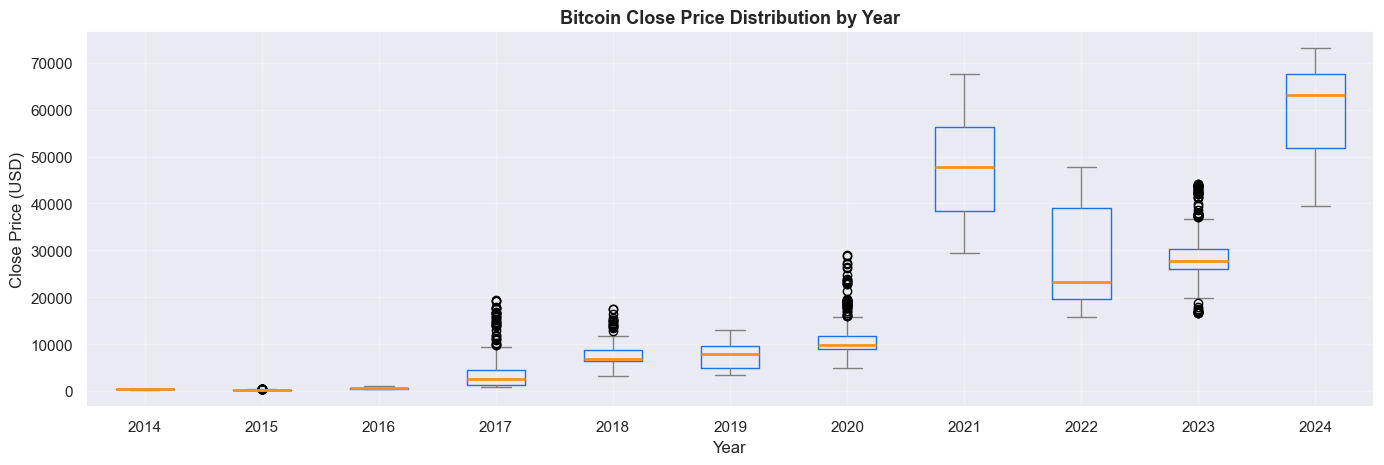

In [29]:
# ── Yearly Boxplot ──
df['Year'] = df.index.year
plt.figure(figsize=(14, 5))
df.boxplot(column='Close', by='Year', figsize=(14, 5),
           boxprops=dict(color='#1A73E8'),
           medianprops=dict(color='#F7931A', linewidth=2),
           whiskerprops=dict(color='gray'),
           capprops=dict(color='gray'))
plt.suptitle('')
plt.title('Bitcoin Close Price Distribution by Year', fontsize=13, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Close Price (USD)')
plt.tight_layout()
plt.savefig('nb1_06_yearly_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

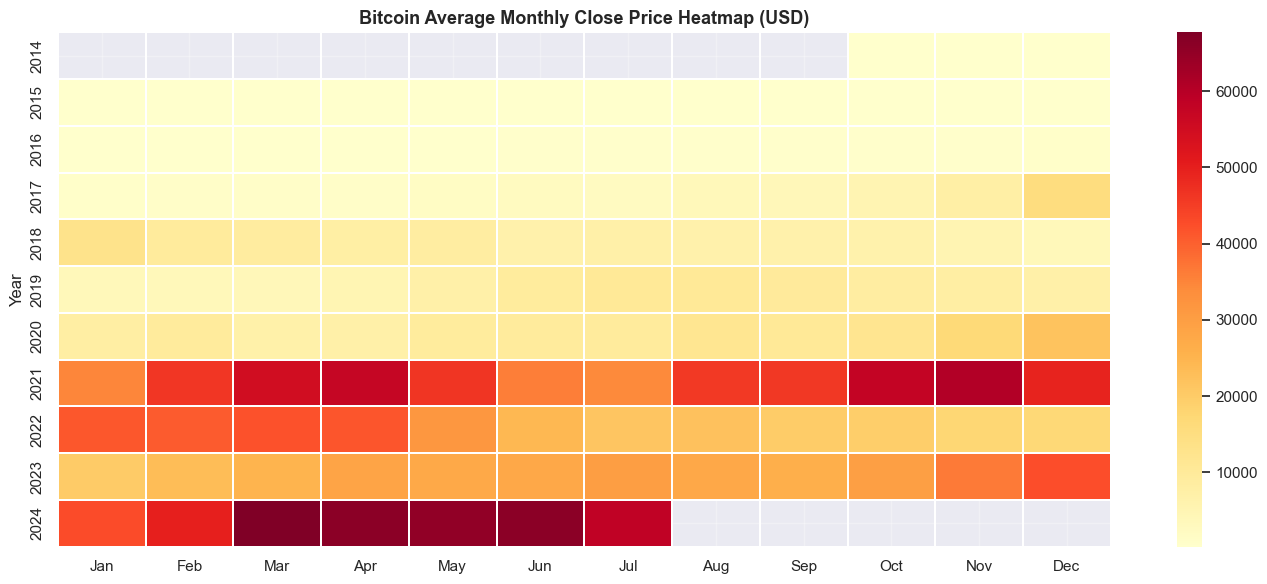

In [30]:
# ── Monthly Average Heatmap ──
df['Month'] = df.index.month
pivot = df.pivot_table(values='Close', index='Year', columns='Month', aggfunc='mean')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f', linewidths=0.3)
plt.title('Bitcoin Average Monthly Close Price Heatmap (USD)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nb1_07_monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

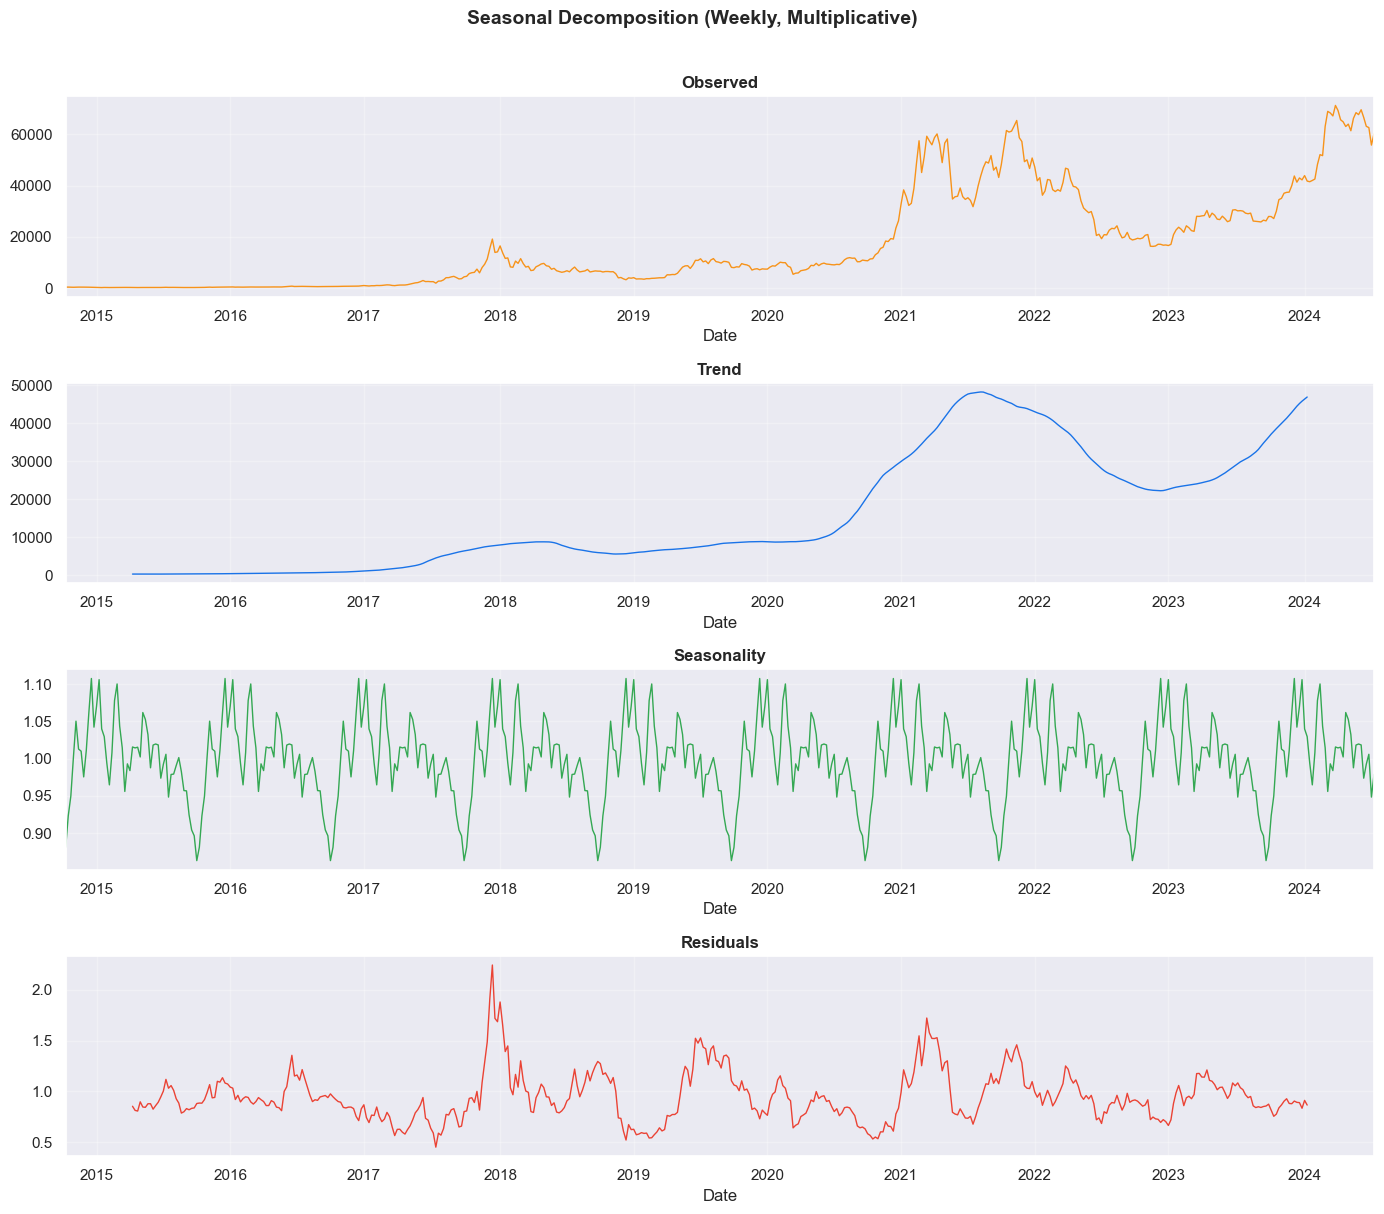

In [31]:
# ── Seasonal Decomposition ──
decomp = seasonal_decompose(df_weekly.ffill(), model='multiplicative', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
comps = [(decomp.observed, 'Observed', '#F7931A'),
         (decomp.trend,    'Trend',    '#1A73E8'),
         (decomp.seasonal, 'Seasonality', '#34A853'),
         (decomp.resid,    'Residuals', '#EA4335')]
for ax, (comp, label, color) in zip(axes, comps):
    comp.plot(ax=ax, color=color, linewidth=1)
    ax.set_title(label, fontsize=12, fontweight='bold')

plt.suptitle('Seasonal Decomposition (Weekly, Multiplicative)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('nb1_08_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ── Stationarity Tests ──
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'\n── ADF Test: {name} ──')
    print(f'  Statistic : {result[0]:.4f}')
    print(f'  p-value   : {result[1]:.6f}')
    for k, v in result[4].items():
        print(f'  Critical ({k}): {v:.4f}')
    verdict = ' STATIONARY' if result[1] < 0.05 else ' NON-STATIONARY'
    print(f'  → {verdict}')

adf_test(df['Close'],        'Raw Close Price')
adf_test(df['Close'].diff(), '1st Difference')
adf_test(np.log(df['Close']).diff(), 'Log Difference')


── ADF Test: Raw Close Price ──
  Statistic : -1.0938
  p-value   : 0.717533
  Critical (1%): -3.4322
  Critical (5%): -2.8624
  Critical (10%): -2.5672
  →  NON-STATIONARY

── ADF Test: 1st Difference ──
  Statistic : -9.2899
  p-value   : 0.000000
  Critical (1%): -3.4322
  Critical (5%): -2.8624
  Critical (10%): -2.5672
  →  STATIONARY

── ADF Test: Log Difference ──
  Statistic : -18.1418
  p-value   : 0.000000
  Critical (1%): -3.4322
  Critical (5%): -2.8624
  Critical (10%): -2.5672
  →  STATIONARY


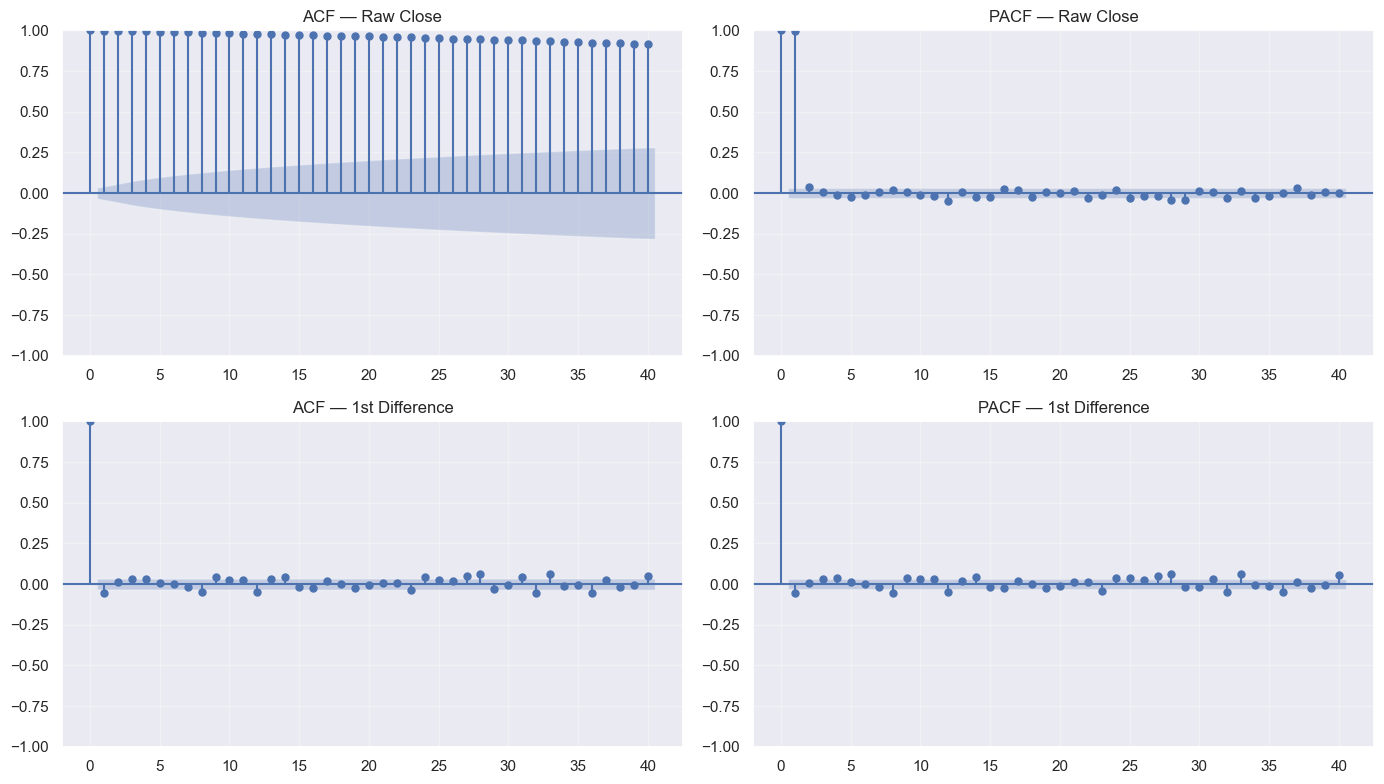

In [34]:
# ── ACF & PACF ──
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(df['Close'].dropna(),           lags=40, ax=axes[0,0], title='ACF — Raw Close')
plot_pacf(df['Close'].dropna(),          lags=40, ax=axes[0,1], title='PACF — Raw Close')
plot_acf(df['Close'].diff().dropna(),    lags=40, ax=axes[1,0], title='ACF — 1st Difference')
plot_pacf(df['Close'].diff().dropna(),   lags=40, ax=axes[1,1], title='PACF — 1st Difference')

plt.tight_layout()
plt.savefig('nb1_09_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Save cleaned dataset for Notebook 2
df.drop(columns=['Year','Month','Daily_Return','Log_Return'], inplace=True, errors='ignore')
df.to_csv('BTC_cleaned.csv')
print(f' Cleaned dataset saved → BTC_cleaned.csv')
print(f'   Shape : {df.shape}')
df.tail()

 Cleaned dataset saved → BTC_cleaned.csv
   Shape : (3566, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2024-07-10,58033.88281,59359.43359,57178.41406,57742.49609,2.617526e+10
2024-07-11,57729.89063,59299.43359,57120.37891,57344.91406,2.870780e+10
2024-07-12,57341.19531,58532.55469,56590.17578,57899.46484,2.560481e+10
2024-07-13,57908.73828,59787.07813,57796.44141,59231.95313,1.708006e+10
2024-07-14,59225.25000,60363.85938,59225.25000,60245.80469,2.140587e+10
